# Byte‑Pair Encoding (BPE) on Trigram Datasets (ACE version)
This notebook loads trigram‑frequency datasets for three collections (*lastfm*, *suno*, *udio*) using the ACE chord extraction (`_functional.lab` files),
runs a Byte‑Pair Encoding algorithm to discover the most common adjacent token pairs, and visualises the top merged patterns.

In [11]:
import os, json, itertools, collections, math, gzip, pickle, pathlib
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Filesystem layout
BASE_DIR = '/workspace/dataset'
COLLECTIONS = ['lastfm', 'suno', 'udio']

INIT_TOKEN = '<init>'
END_TOKEN  = '<end>'

In [12]:
def parse_functional_lab(path):
    """Parse _functional.lab -> list of chord labels (raw Roman numerals)."""
    labels = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[2] != 'N':
                labels.append(parts[2])
    return labels


def load_chord_sequences(collection_name):
    """Return a list of full chord streams for one collection,
       reading Roman numerals directly from _functional.lab files."""
    seqs = []
    root = os.path.join(BASE_DIR, collection_name)

    for song_id in os.listdir(root):
        song_dir = os.path.join(root, song_id)
        if not os.path.isdir(song_dir):
            continue
        fp = os.path.join(song_dir, f'{song_id}_functional.lab')
        if not os.path.isfile(fp):
            continue

        tokens = parse_functional_lab(fp)
        if not tokens:
            continue

        seqs.append(tuple([INIT_TOKEN] + tokens + [END_TOKEN]))

    return seqs


def to_trigram_tokens(chord_seq):
    """Extract trigrams where all 3 chords are different."""
    trigram_list = []
    for i in range(len(chord_seq) - 2):
        tri = tuple(chord_seq[i:i+3])
        if len(set(tri)) == 3:
            trigram_list.append(tri)
    return tuple(trigram_list)


print('Data loading functions defined')

Data loading functions defined


In [13]:
def get_pair_frequencies(seq_counts):
    pair_freq = Counter()
    for tokens, cnt in seq_counts:
        for i in range(len(tokens) - 1):
            pair_freq[(tokens[i], tokens[i+1])] += cnt
    return pair_freq

def merge_pair(seq_counts, pair_to_merge, new_tok):
    a, b = pair_to_merge
    merged = []
    for tokens, cnt in seq_counts:
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens) - 1 and tokens[i] == a and tokens[i+1] == b:
                new_tokens.append(new_tok)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        merged.append((tuple(new_tokens), cnt))
    return merged

def byte_pair_encoding(seq_counts, num_merges=150):
    merge_rules, merge_history = {}, []
    for m in range(num_merges):
        pf = get_pair_frequencies(seq_counts)
        if not pf:
            break
        (best_pair, freq) = pf.most_common(1)[0]
        new_tok = f'MERGE_{m}'
        merge_rules[new_tok] = best_pair
        merge_history.append((best_pair, freq))
        seq_counts = merge_pair(seq_counts, best_pair, new_tok)
    return merge_rules, merge_history

def expand_token(tok, rules):
    if tok not in rules:
        return [tok]
    a, b = rules[tok]
    return expand_token(a, rules) + expand_token(b, rules)

In [14]:
from collections import Counter

results = {}
for name in COLLECTIONS:
    seqs = load_chord_sequences(name)
    trigram_seqs = [to_trigram_tokens(s) for s in seqs]
    seq_counts = list(Counter(trigram_seqs).items())
    rules, history = byte_pair_encoding(seq_counts, num_merges=150)
    results[name] = {"rules": rules, "history": history}
    print(f"{name}: {len(seqs)} songs, {len(history)} merges")

lastfm: 18916 songs, 150 merges
suno: 18978 songs, 150 merges
udio: 19031 songs, 150 merges


In [15]:
# Search for specific trigrams in BPE merge history

trigram_to_find = ('vi', 'IV', 'I')
for c in COLLECTIONS:
    for idx, ((a, b), freq) in enumerate(results[c]['history'], 1):
        if a == trigram_to_find or b == trigram_to_find:
            print(f"Found at index {idx} with frequency {freq} in {c}")

Found at index 5 with frequency 1898 in lastfm
Found at index 7 with frequency 1520 in lastfm
Found at index 57 with frequency 447 in lastfm
Found at index 2 with frequency 13419 in suno
Found at index 4 with frequency 4976 in suno
Found at index 70 with frequency 884 in suno
Found at index 4 with frequency 1671 in udio
Found at index 9 with frequency 1253 in udio


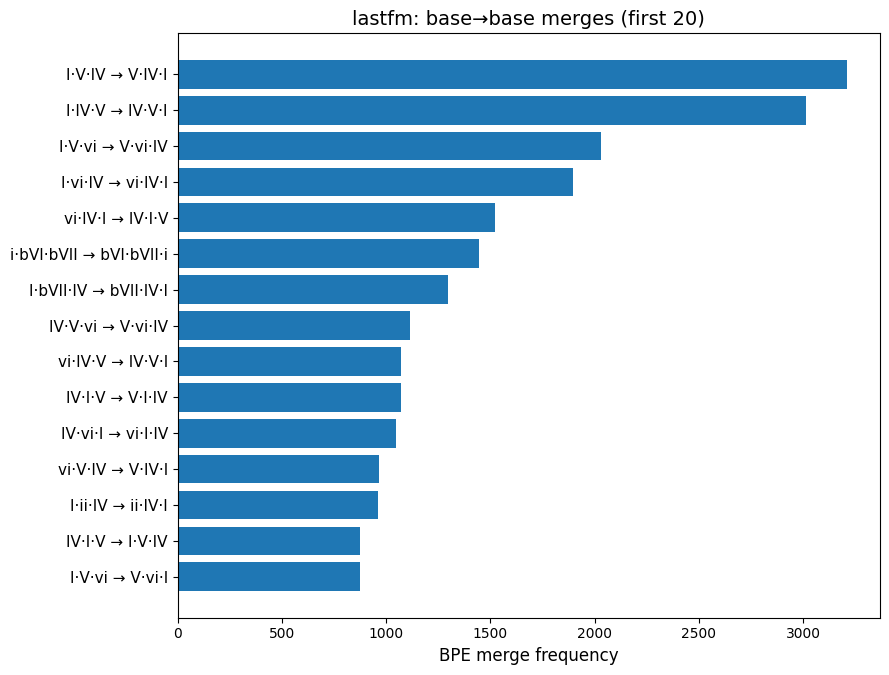

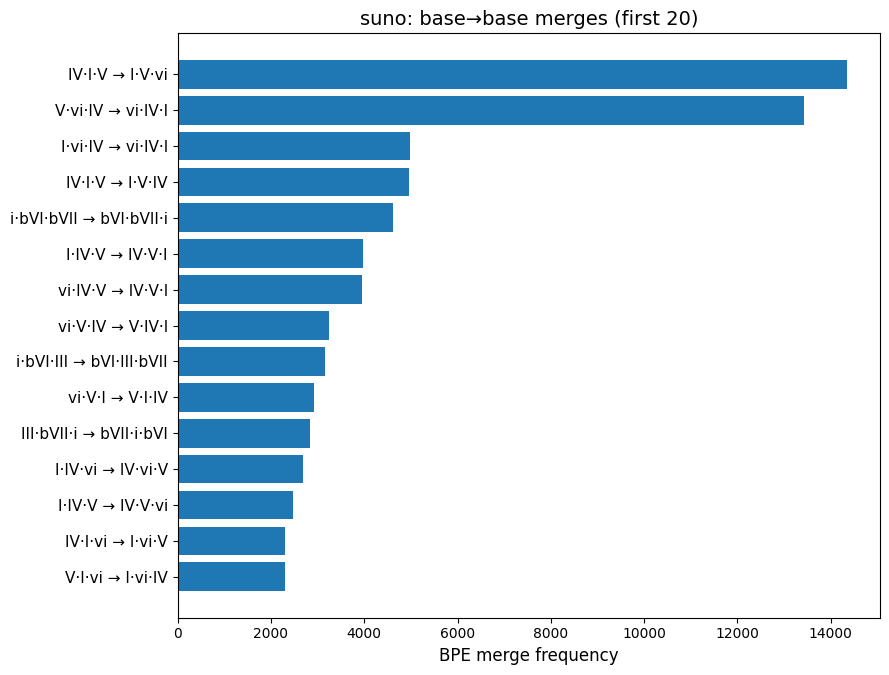

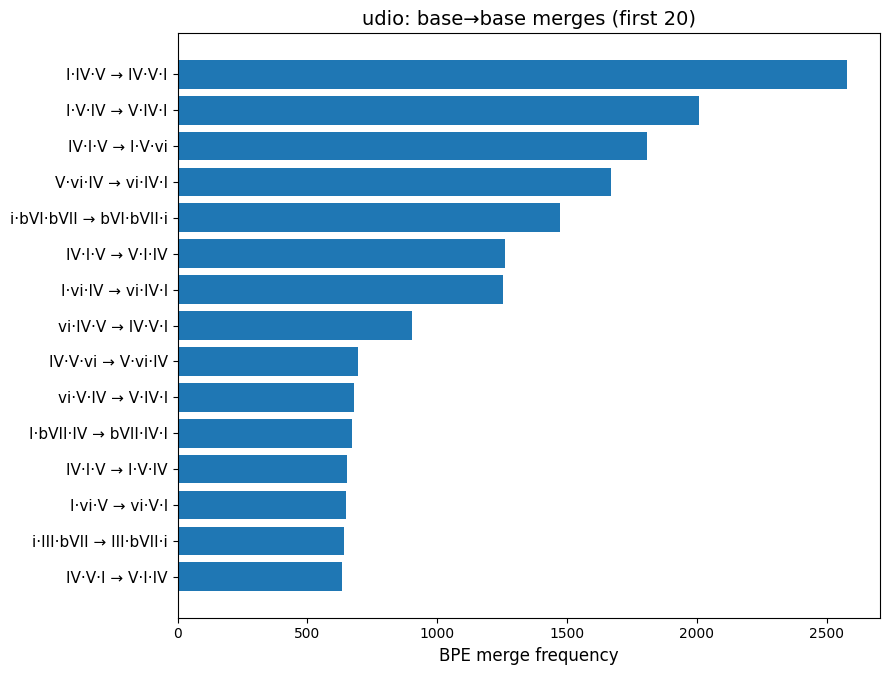

In [16]:
# Per-corpus plots of BPE base-to-base merges

import numpy as np
import matplotlib.pyplot as plt

def expand_base_trigrams(tok, rules):
    """Return list of base trigrams inside tok (MERGE_x or tuple)."""
    return expand_token(tok, rules)

def token_as_text_single(tok, rules):
    """Return 'I·V·vi' if tok expands to exactly one base trigram.
    Return None for composite tokens, which we skip."""
    tris = expand_base_trigrams(tok, rules)
    if len(tris) != 1:
        return None
    return "·".join(tris[0])

def _extract_freq(meta):
    """Normalize history value to an integer frequency."""
    if isinstance(meta, dict):
        return int(meta.get("freq", 0))
    return int(meta)

def collect_base_base_rows(res, top_k=20):
    """From one corpus result, collect first top_k merges that are base-to-base only."""
    rules = res["rules"]
    hist = res["history"][:top_k] if top_k is not None else res["history"]
    rows = []
    for (a, b), meta in hist:
        L = token_as_text_single(a, rules)
        R = token_as_text_single(b, rules)
        if L is None or R is None:
            continue
        rows.append((f"{L} → {R}", _extract_freq(meta)))
    rows.sort(key=lambda x: x[1], reverse=True)
    return rows

def plot_per_corpus_bars(results, collections, top_k=20, save_dir=None):
    """Make one horizontal bar chart per corpus."""
    for corpus in collections:
        res = results[corpus]
        rows = collect_base_base_rows(res, top_k=top_k)
        if not rows:
            print(f"[{corpus}] No base→base merges in first {top_k}.")
            continue
        labels, vals = zip(*rows)
        y = np.arange(len(labels))
        fig_h = 0.35 * len(labels) + 1.6
        plt.figure(figsize=(9, fig_h))
        plt.barh(y, vals)
        plt.yticks(y, labels, fontsize=11)
        plt.xlabel("BPE merge frequency", fontsize=12)
        plt.title(f"{corpus}: base→base merges (first {top_k})", fontsize=14)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        if save_dir:
            out = f"{save_dir}/{corpus}_bpe_base_base_top{top_k}.png"
            plt.savefig(out, dpi=150)
            plt.close()
            print(f"Saved {out}")
        else:
            plt.show()

COLLECTIONS = ["lastfm", "suno", "udio"]
plot_per_corpus_bars(results, COLLECTIONS, top_k=20, save_dir=None)

In [17]:
# Raw trigram frequencies analysis

def get_raw_trigram_frequencies(collection_name):
    """Get raw trigram frequencies from the original sequences"""
    print(f"\nAnalyzing {collection_name}...")
    chord_streams = load_chord_sequences(collection_name)
    print(f"   Loaded {len(chord_streams)} songs")
    
    all_trigrams = []
    for seq in chord_streams:
        trigrams = to_trigram_tokens(seq)
        all_trigrams.extend(trigrams)
    
    trigram_counts = Counter(all_trigrams)
    print(f"   Total trigrams: {len(all_trigrams)}")
    print(f"   Unique trigrams: {len(trigram_counts)}")
    
    return trigram_counts

raw_trigrams = {}
for col in COLLECTIONS:
    raw_trigrams[col] = get_raw_trigram_frequencies(col)

# Check specific important trigrams
target_trigrams = [
    ('vi', 'IV', 'I'),
    ('I', 'V', 'vi'), 
    ('V', 'IV', 'I'),
    ('I', 'IV', 'V'),
    ('IV', 'I', 'V')
]

print(f"\nChecking specific trigrams that should be common:")
print(f"{'Trigram':<20} {'LastFM':<10} {'Suno':<10} {'Udio':<10}")
print("-" * 55)

for trigram in target_trigrams:
    freqs = [raw_trigrams[col].get(trigram, 0) for col in COLLECTIONS]
    trig_str = "·".join(trigram)
    print(f"{trig_str:<20} {freqs[0]:<10} {freqs[1]:<10} {freqs[2]:<10}")

# Top 10 raw trigrams per collection
print(f"\nTop 10 raw trigrams per collection:")
for col in COLLECTIONS:
    print(f"\n{col.upper()}:")
    for trigram, freq in raw_trigrams[col].most_common(10):
        trig_str = "·".join(trigram)
        print(f"  {trig_str:<25} {freq}")

# Check unique chord symbols
all_unique_chords = set()
for col in COLLECTIONS:
    for trigram in raw_trigrams[col].keys():
        all_unique_chords.update(trigram)

common_chords = ['I', 'IV', 'V', 'vi', 'ii', 'iii', 'bVI', 'bVII']
print(f"\nExpected chords found: {[chord for chord in common_chords if chord in all_unique_chords]}")
print(f"Total unique chord symbols: {len(all_unique_chords)}")


Analyzing lastfm...
   Loaded 18916 songs
   Total trigrams: 903073
   Unique trigrams: 33970

Analyzing suno...
   Loaded 18978 songs
   Total trigrams: 1085240
   Unique trigrams: 20770

Analyzing udio...
   Loaded 19031 songs
   Total trigrams: 650804
   Unique trigrams: 29755

Checking specific trigrams that should be common:
Trigram              LastFM     Suno       Udio      
-------------------------------------------------------
vi·IV·I              5210       23047      3896      
I·V·vi               4419       21593      3691      
V·IV·I               6475       10171      4265      
I·IV·V               5925       8832       4928      
IV·I·V               9793       26725      7418      

Top 10 raw trigrams per collection:

LASTFM:
  IV·I·V                    9793
  IV·V·I                    7229
  V·I·IV                    7029
  V·IV·I                    6475
  I·IV·V                    5925
  I·V·IV                    5847
  vi·IV·I                   5210
  I·V·vi  

In [18]:
# Real trigram pair frequencies (Suno-ranked)

def get_trigram_pair_frequencies(collection_name):
    """Get frequencies of adjacent trigram pairs from raw sequences"""
    chord_streams = load_chord_sequences(collection_name)
    trigram_sequences = []
    for seq in chord_streams:
        trigrams = to_trigram_tokens(seq)
        if len(trigrams) >= 2:
            trigram_sequences.append(trigrams)
    pair_counts = Counter()
    for trigram_seq in trigram_sequences:
        for i in range(len(trigram_seq) - 1):
            pair = (trigram_seq[i], trigram_seq[i+1])
            pair_counts[pair] += 1
    return pair_counts

print("Computing real trigram pair frequencies...")
real_pair_freqs = {}
for col in COLLECTIONS:
    print(f"   Processing {col}...")
    real_pair_freqs[col] = get_trigram_pair_frequencies(col)

# Get Suno's top trigram pairs
num = 40
suno_top_pairs = real_pair_freqs['suno'].most_common(num)

print(f"\nTop {num} trigram pairs in Suno with cross-collection frequencies:")
print(f"{'Trigram Pair':<50} {'LastFM':<8} {'Suno':<8} {'Udio':<8}")
print("-" * 80)

freq_matrix_suno = []
pair_labels_suno = []

for (trigram1, trigram2), suno_freq in suno_top_pairs:
    tri1_str = "·".join(trigram1)
    tri2_str = "·".join(trigram2) 
    pair_label = f"{tri1_str} → {tri2_str}"
    pair_key = (trigram1, trigram2)
    lastfm_freq = real_pair_freqs['lastfm'].get(pair_key, 0)
    udio_freq = real_pair_freqs['udio'].get(pair_key, 0)
    print(f"{pair_label:<50} {lastfm_freq:<8} {suno_freq:<8} {udio_freq:<8}")
    freq_matrix_suno.append([lastfm_freq, suno_freq, udio_freq])
    pair_labels_suno.append(pair_label)

freq_mat_suno = np.array(freq_matrix_suno)

# Cross-collection analysis
print(f"\nCross-collection analysis:")
non_zero_all = sum(1 for row in freq_mat_suno if all(f > 0 for f in row))
suno_only = sum(1 for row in freq_mat_suno if row[1] > 0 and row[0] == 0 and row[2] == 0)
print(f"Pairs in ALL 3 collections: {non_zero_all}")
print(f"Pairs in only Suno: {suno_only}")

pairs_list = [('lastfm', 'suno'), ('suno', 'udio'), ('lastfm', 'udio')]
for col1, col2 in pairs_list:
    idx1 = COLLECTIONS.index(col1)
    idx2 = COLLECTIONS.index(col2)
    corr = np.corrcoef(freq_mat_suno[:, idx1], freq_mat_suno[:, idx2])[0, 1]
    print(f"Correlation {col1}-{col2}: {corr:.3f}")

Computing real trigram pair frequencies...
   Processing lastfm...
   Processing suno...
   Processing udio...

Top 40 trigram pairs in Suno with cross-collection frequencies:
Trigram Pair                                       LastFM   Suno     Udio    
--------------------------------------------------------------------------------
IV·I·V → I·V·vi                                    2016     14341    1809    
vi·IV·I → IV·I·V                                   2015     14233    1764    
I·V·vi → V·vi·IV                                   2031     14198    1745    
V·vi·IV → vi·IV·I                                  1855     13419    1671    
I·vi·IV → vi·IV·I                                  1898     4976     1253    
IV·I·V → I·V·IV                                    3113     4953     1982    
V·IV·I → IV·I·V                                    2902     4899     1880    
i·bVI·bVII → bVI·bVII·i                            1447     4614     1473    
bVI·bVII·i → bVII·i·bVI                  

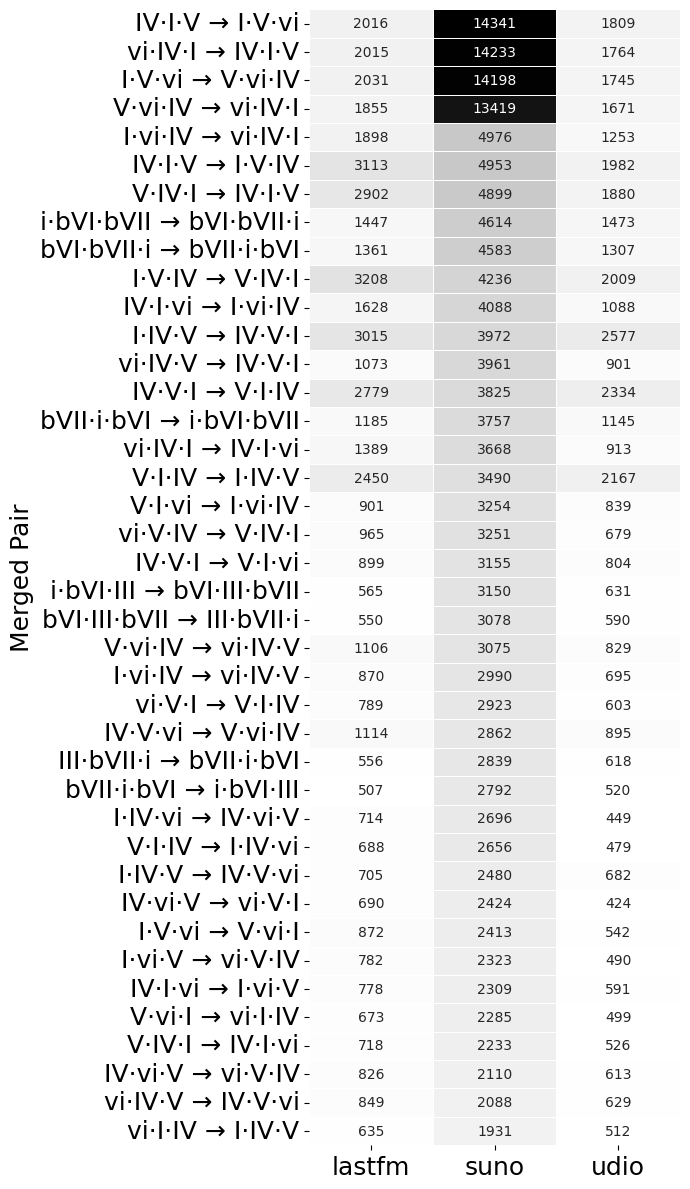

In [22]:
# Heatmap: Suno-ranked trigram pairs

text_size = 18
t_size = 18
col_width_in = 2
row_height_in = 0.25

fig_w = col_width_in * len(COLLECTIONS) + 1.0
fig_h = row_height_in * len(pair_labels_suno) + 2.0

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    freq_mat_suno,
    xticklabels=COLLECTIONS,
    yticklabels=pair_labels_suno,
    cmap='Greys',
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    cbar=False
)
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), fontsize=t_size, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=t_size)
plt.ylabel('Merged Pair', fontsize=18)
plt.tight_layout()
plt.show()

Top 40 trigram pairs in Udio with cross-collection frequencies:
Trigram Pair                                       LastFM   Suno     Udio    
--------------------------------------------------------------------------------
I·IV·V → IV·V·I                                    3015     3972     2577    
IV·V·I → V·I·IV                                    2779     3825     2334    
V·I·IV → I·IV·V                                    2450     3490     2167    
I·V·IV → V·IV·I                                    3208     4236     2009    
IV·I·V → I·V·IV                                    3113     4953     1982    
V·IV·I → IV·I·V                                    2902     4899     1880    
IV·I·V → I·V·vi                                    2016     14341    1809    
vi·IV·I → IV·I·V                                   2015     14233    1764    
I·V·vi → V·vi·IV                                   2031     14198    1745    
V·vi·IV → vi·IV·I                                  1855     13419    1671  

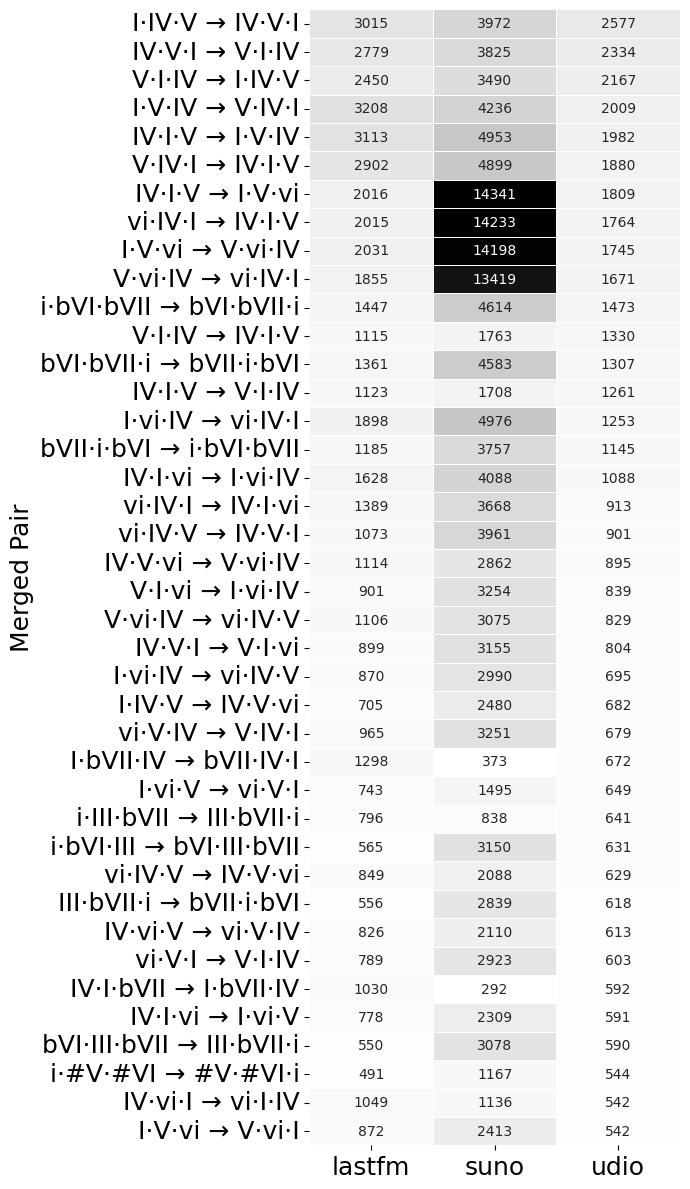

In [20]:
# Real trigram pair frequencies (Udio-ranked)

udio_top_pairs = real_pair_freqs['udio'].most_common(num)

print(f"Top {num} trigram pairs in Udio with cross-collection frequencies:")
print(f"{'Trigram Pair':<50} {'LastFM':<8} {'Suno':<8} {'Udio':<8}")
print("-" * 80)

freq_matrix_udio = []
pair_labels_udio = []

for (trigram1, trigram2), udio_freq in udio_top_pairs:
    tri1_str = "·".join(trigram1)
    tri2_str = "·".join(trigram2)
    pair_label = f"{tri1_str} → {tri2_str}"
    pair_key = (trigram1, trigram2)
    lastfm_freq = real_pair_freqs['lastfm'].get(pair_key, 0)
    suno_freq = real_pair_freqs['suno'].get(pair_key, 0)
    print(f"{pair_label:<50} {lastfm_freq:<8} {suno_freq:<8} {udio_freq:<8}")
    freq_matrix_udio.append([lastfm_freq, suno_freq, udio_freq])
    pair_labels_udio.append(pair_label)

freq_mat_udio = np.array(freq_matrix_udio)

# Cross-collection analysis
print(f"\nCross-collection analysis:")
non_zero_all = sum(1 for row in freq_mat_udio if all(f > 0 for f in row))
udio_only = sum(1 for row in freq_mat_udio if row[2] > 0 and row[0] == 0 and row[1] == 0)
print(f"Pairs in ALL 3 collections: {non_zero_all}")
print(f"Pairs in only Udio: {udio_only}")

for col1, col2 in pairs_list:
    idx1 = COLLECTIONS.index(col1)
    idx2 = COLLECTIONS.index(col2)
    corr = np.corrcoef(freq_mat_udio[:, idx1], freq_mat_udio[:, idx2])[0, 1]
    print(f"Correlation {col1}-{col2}: {corr:.3f}")

# Heatmap
fig_w = col_width_in * len(COLLECTIONS) + 1.0
fig_h = row_height_in * len(pair_labels_udio) + 2.0

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    freq_mat_udio,
    xticklabels=COLLECTIONS,
    yticklabels=pair_labels_udio,
    cmap='Greys',
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    cbar=False
)
ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), fontsize=t_size, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=t_size)
plt.ylabel('Merged Pair', fontsize=18)
plt.tight_layout()
plt.show()

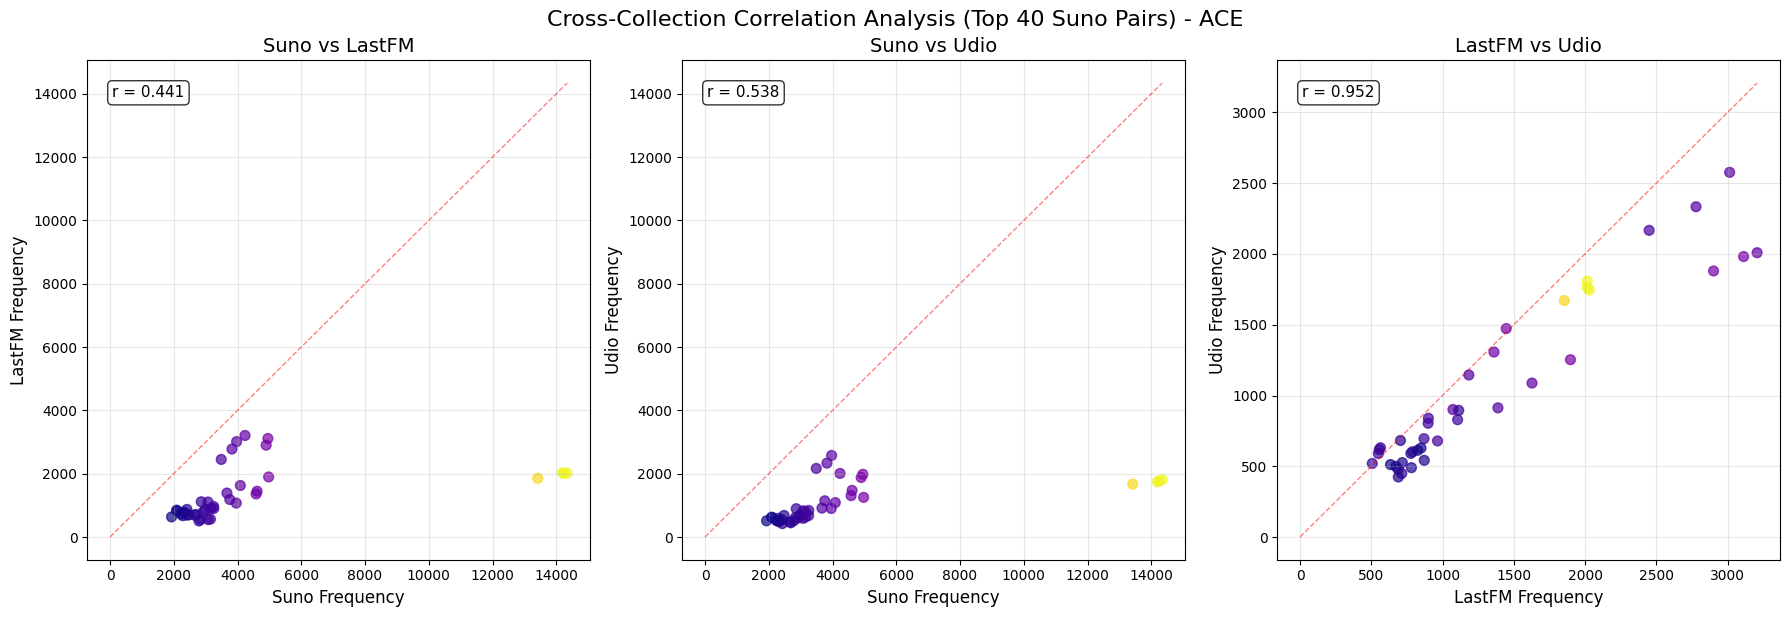


Most divergent patterns (high in one, low in others):
IV·I·V → I·V·vi                          | CV: 0.97 | Dominant in: suno (14341)
vi·IV·I → IV·I·V                         | CV: 0.97 | Dominant in: suno (14233)
I·V·vi → V·vi·IV                         | CV: 0.97 | Dominant in: suno (14198)
V·vi·IV → vi·IV·I                        | CV: 0.97 | Dominant in: suno (13419)
I·vi·IV → vi·IV·I                        | CV: 0.60 | Dominant in: suno (4976)
IV·I·V → I·V·IV                          | CV: 0.37 | Dominant in: suno (4953)
V·IV·I → IV·I·V                          | CV: 0.39 | Dominant in: suno (4899)
i·bVI·bVII → bVI·bVII·i                  | CV: 0.59 | Dominant in: suno (4614)
bVI·bVII·i → bVII·i·bVI                  | CV: 0.63 | Dominant in: suno (4583)
I·V·IV → V·IV·I                          | CV: 0.29 | Dominant in: suno (4236)

Perfect overlaps (similar frequencies across all collections):
IV·I·V → I·V·IV                          | LastFM: 3113, Suno: 4953, Udio: 1982
V·IV·I 

In [21]:
# Scatter plot: cross-collection correlation analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

lastfm_freqs = freq_mat_suno[:, 0]
suno_freqs = freq_mat_suno[:, 1]
udio_freqs = freq_mat_suno[:, 2]

comparisons = [
    (suno_freqs, lastfm_freqs, 'Suno vs LastFM', 'Suno Frequency', 'LastFM Frequency'),
    (suno_freqs, udio_freqs, 'Suno vs Udio', 'Suno Frequency', 'Udio Frequency'),
    (lastfm_freqs, udio_freqs, 'LastFM vs Udio', 'LastFM Frequency', 'Udio Frequency')
]

for i, (x_data, y_data, title, xlabel, ylabel) in enumerate(comparisons):
    ax = axes[i]
    scatter = ax.scatter(x_data, y_data, alpha=0.7, s=50, c=suno_freqs, cmap='plasma')
    max_val = max(max(x_data), max(y_data))
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, linewidth=1)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)
    correlation = np.corrcoef(x_data, y_data)[0, 1]
    ax.text(0.05, 0.95, f'r = {correlation:.3f}', transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.suptitle(f'Cross-Collection Correlation Analysis (Top {num} Suno Pairs) - ACE', fontsize=16, y=1.02)
plt.show()

# Most divergent patterns
print("\nMost divergent patterns (high in one, low in others):")
for i, pair in enumerate(pair_labels_suno[:10]):
    lastfm, suno, udio = freq_mat_suno[i]
    freqs = [lastfm, suno, udio]
    if sum(freqs) > 0:
        cv = np.std(freqs) / np.mean(freqs)
        max_col = COLLECTIONS[np.argmax(freqs)]
        print(f"{pair:<40} | CV: {cv:.2f} | Dominant in: {max_col} ({max(freqs)})")

print("\nPerfect overlaps (similar frequencies across all collections):")
count = 0
for i, pair in enumerate(pair_labels_suno):
    lastfm, suno, udio = freq_mat_suno[i]
    if min(lastfm, suno, udio) > 50:
        cv = np.std([lastfm, suno, udio]) / np.mean([lastfm, suno, udio])
        if cv < 0.5:
            print(f"{pair:<40} | LastFM: {lastfm}, Suno: {suno}, Udio: {udio}")
            count += 1
            if count >= 5:
                break